# 6PASNMLN Machine Learning in Neuroscience
## Exploratory Code for Summative
#### K22016090

##### This code explores different possible pipelines for assingment

## Import Libraries into workspace

In [291]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from numpy.random import default_rng
import pandas as pd     
import seaborn as sns          
import xgboost as xgb
from scipy import stats

# for checking your directory
import os 

from sklearn.model_selection import train_test_split, learning_curve 
from sklearn.preprocessing import StandardScaler         
from sklearn.pipeline import Pipeline        
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_error 

from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import permutation_test_score

# Models:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor


## 1. Preperation of Data
#### Structural MRI Data
##### 116 MRI-derived features for 740 healthy participants

We first need to load the data

In [292]:
print(os.getcwd()) # check we are in the right working directory

/Users/Johanna/Documents/Python/MLN/Summative/Code


In [293]:
# Load and check the data
t1_data = pd.read_csv('data/data.csv', sep=',')
print(t1_data.shape)
print(t1_data.columns)

(740, 118)
Index(['participant_id', 'Left-Lateral-Ventricle', 'Left-Inf-Lat-Vent',
       'Left-Cerebellum-White-Matter', 'Left-Cerebellum-Cortex',
       'Left-Thalamus-Proper', 'Left-Caudate', 'Left-Putamen', 'Left-Pallidum',
       '3rd-Ventricle',
       ...
       'rh_rostralmiddlefrontal', 'rh_superiorfrontal', 'rh_superiorparietal',
       'rh_superiortemporal', 'rh_supramarginal', 'rh_frontalpole',
       'rh_temporalpole', 'rh_transversetemporal', 'rh_insula',
       'IST_intelligence_total'],
      dtype='object', length=118)


### Visualising Data

In [294]:
## to inspect our target predictor variable - IST_intelligence_total

IST_intel_tot = t1_data.iloc[:, -1]   # since it is the last column
print(IST_intel_tot.name)
print(IST_intel_tot.describe())


IST_intelligence_total
count    740.000000
mean     200.360811
std       40.207289
min       68.000000
25%      172.000000
50%      205.000000
75%      230.000000
max      295.000000
Name: IST_intelligence_total, dtype: float64


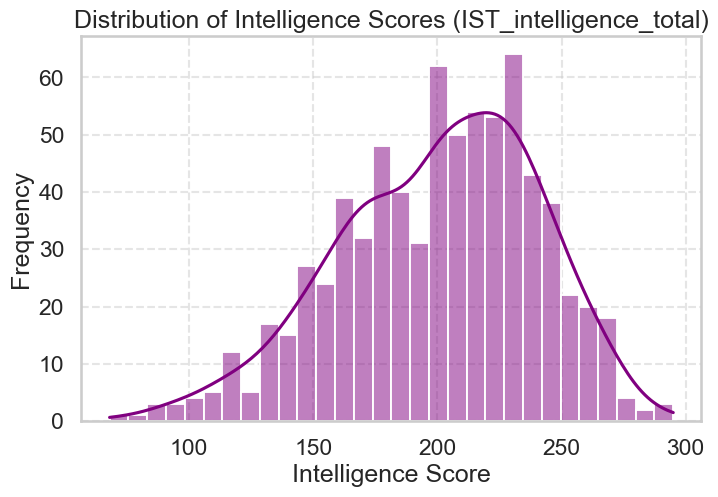

In [295]:
## to visualise the distribution of intelligence scores 

plt.figure(figsize=(8, 5))
sns.histplot(IST_intel_tot, bins=30, kde=True, color='purple')
plt.title('Distribution of Intelligence Scores (IST_intelligence_total)')
plt.xlabel('Intelligence Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## gives:
## A histogram of intelligence scores
## A smoothed density curve (KDE)
## A clear visual check for normality or skewness

### Clean data

In [296]:
# check data types: 
t1_data.dtypes

# drop non-numeric columns (participant ID)
t1_data_numeric = t1_data.select_dtypes(include=['number'])
## IDs do not carry any predictive values and could cause data leakage

# checking for missing values and drop if there are any
print("Missing values per column:")
print(t1_data_numeric.isnull().sum().sum()) 
# the first sum gives you the number of missing values per column, the addition of the second sums up acrros the entire series giving you the total of missing values across the dataframe


Missing values per column:
0


In [297]:
# Drop any feature with minimal variance
# calculate the variance for each feature
feature_variances = t1_data_numeric.drop(columns=['IST_intelligence_total']).var()

# Identify features with 0 variance
zero_var_features = feature_variances[feature_variances == 0].index.tolist()

# Identify near-zero variance features (variance < threshold)
# I am going a very small threshold to catch essentially constant features
variance_threshold = 0.01
near_zero_var_features = feature_variances[
    (feature_variances > 0) & (feature_variances < variance_threshold)
].index.tolist()

# Report
print("="*60)
print("VARIANCE-BASED FEATURE REMOVAL")
print("="*60)
print(f"Total features before removal: {len(t1_data_numeric.columns) - 1}")  # -1 for target variable
print(f"\nZero variance features found: {len(zero_var_features)}")
if zero_var_features:
    print(f"  {zero_var_features}")

print(f"\nNear-zero variance features (var < {variance_threshold}): {len(near_zero_var_features)}")
if near_zero_var_features:
    print(f"  {near_zero_var_features}")

# Remove zero variance features (keep near-zero for now, can decide later)
if zero_var_features:
    t1_data_numeric = t1_data_numeric.drop(columns=zero_var_features)
    print(f"\n✓ Removed {len(zero_var_features)} zero-variance features")
else:
    print("\n✓ No zero-variance features to remove")

print(f"\nTotal features after removal: {len(t1_data_numeric.columns) - 1}")  # -1 for target
print("="*60)

VARIANCE-BASED FEATURE REMOVAL
Total features before removal: 116

Zero variance features found: 7
  ['Left-WM-hypointensities', 'Right-WM-hypointensities', 'Left-non-WM-hypointensities', 'Right-non-WM-hypointensities', 'stat_scan', 'scan_end', 'trigger']

Near-zero variance features (var < 0.01): 0

✓ Removed 7 zero-variance features

Total features after removal: 109


In [298]:
# check that dropping of features worked
t1_data_numeric.dtypes

print(t1_data_numeric.shape)
print(t1_data_numeric.columns)

(740, 110)
Index(['Left-Lateral-Ventricle', 'Left-Inf-Lat-Vent',
       'Left-Cerebellum-White-Matter', 'Left-Cerebellum-Cortex',
       'Left-Thalamus-Proper', 'Left-Caudate', 'Left-Putamen', 'Left-Pallidum',
       '3rd-Ventricle', '4th-Ventricle',
       ...
       'rh_rostralmiddlefrontal', 'rh_superiorfrontal', 'rh_superiorparietal',
       'rh_superiortemporal', 'rh_supramarginal', 'rh_frontalpole',
       'rh_temporalpole', 'rh_transversetemporal', 'rh_insula',
       'IST_intelligence_total'],
      dtype='object', length=110)


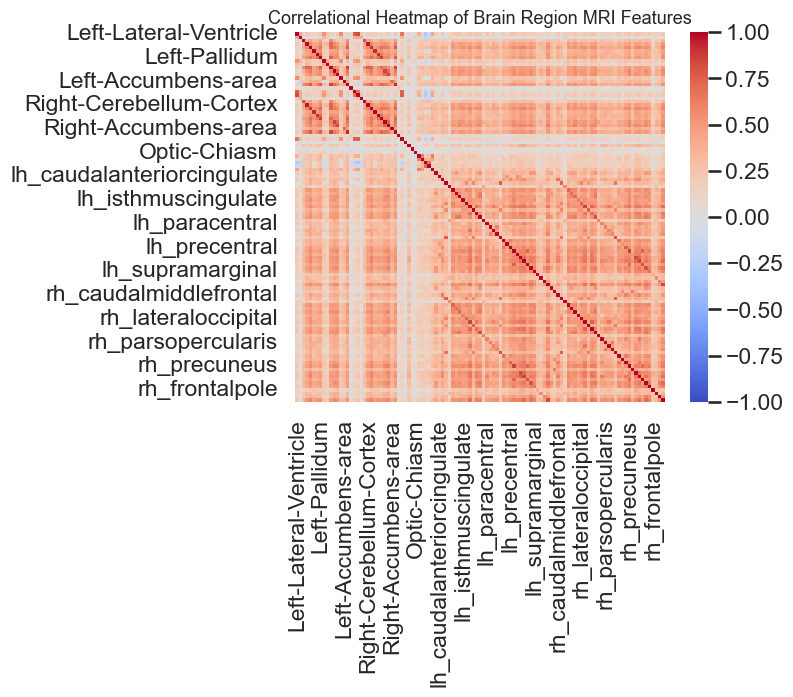

In [299]:
# visualise the corerlation matrix between different brain regions 
# source: https://seaborn.pydata.org/generated/seaborn.heatmap.html

corr_matrix = t1_data_numeric.drop(columns=['IST_intelligence_total']).corr()

sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlational Heatmap of Brain Region MRI Features', fontsize=13)
plt.show()

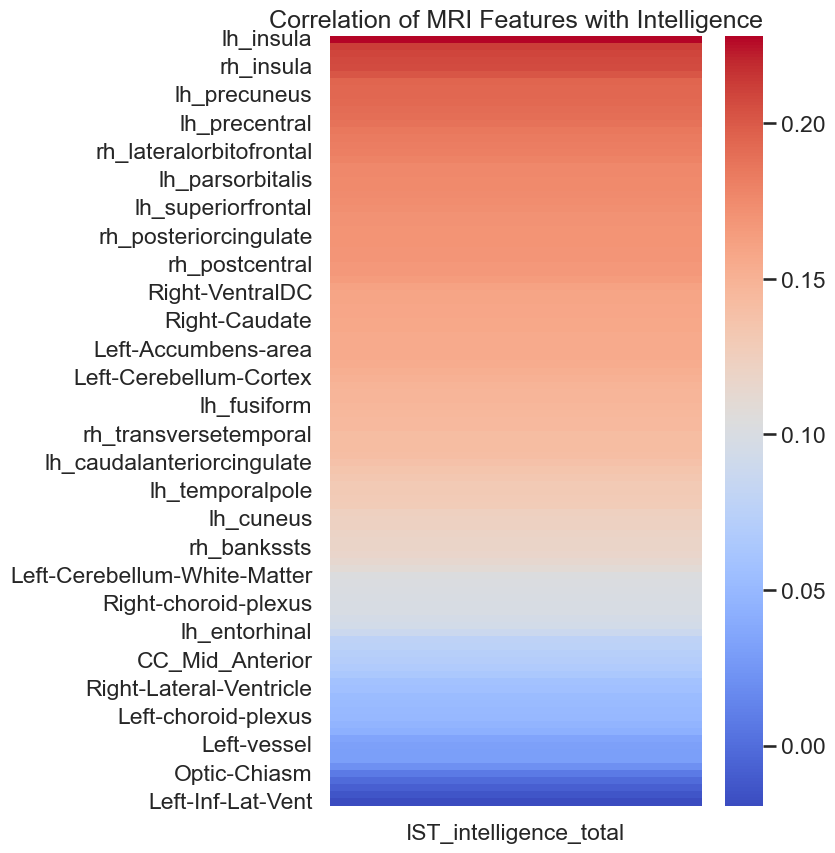

In [300]:
## visualise how correlated each regions is with ONLY intelligence
corrs = t1_data_numeric.corr()['IST_intelligence_total'].drop('IST_intelligence_total').sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(corrs.to_frame(), cmap='coolwarm', annot=False)
plt.title('Correlation of MRI Features with Intelligence')
plt.show()

/var/folders/nf/9_zmrgbs66z1st9tf7szd_rr0000gq/T/ipykernel_92043/11765185.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corrs_2.head(15).values, y=corrs_2.head(15).index, palette='viridis')


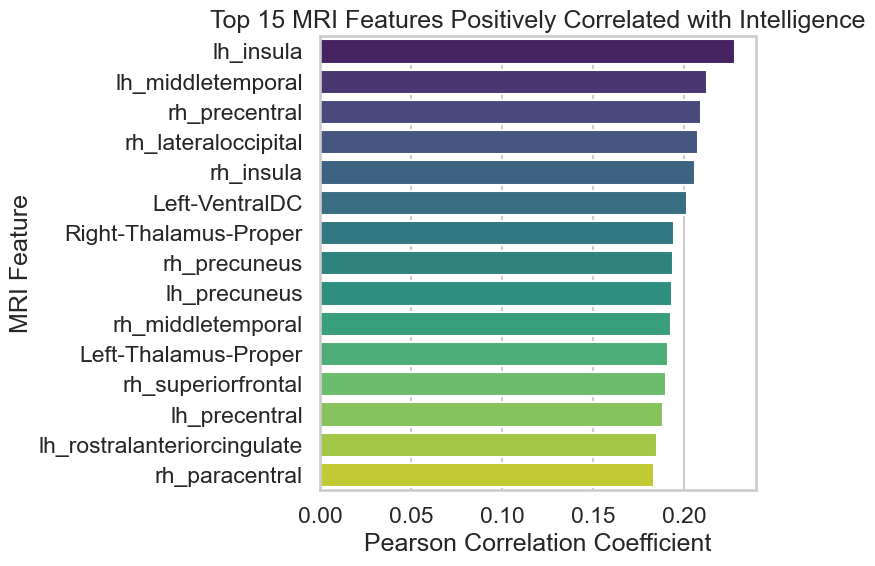

,Correlation
lh_insula,0.228122
lh_middletemporal,0.212487
rh_precentral,0.209114
rh_lateraloccipital,0.207602
rh_insula,0.205986
Left-VentralDC,0.201384
Right-Thalamus-Proper,0.194428
rh_precuneus,0.193680
lh_precuneus,0.193502
rh_middletemporal,0.192876


In [301]:
# exploration into: sorted correlation barplot of the top 15 features most correlated with intelligence

# Compute correlations with intellegince variable
corrs_2 = (
    t1_data_numeric.corr()['IST_intelligence_total']
    .drop('IST_intelligence_total')  # remove self-correlation
    .sort_values(ascending=False)
)

# plot it: 
# source: https://seaborn.pydata.org/generated/seaborn.barplot.html#seaborn.barplot 
plt.figure(figsize=(8, 6))
sns.barplot(x=corrs_2.head(15).values, y=corrs_2.head(15).index, palette='viridis')
plt.title('Top 15 MRI Features Positively Correlated with Intelligence')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('MRI Feature')
plt.tight_layout()
plt.show()

## view full table:
corrs_2.to_frame(name='Correlation').head(20)

### Finish cleaning

In [302]:
## Now that all the types of correlations have been explore, finish cleaning the data

# Separate features and target
X = t1_data_numeric.drop(columns=['IST_intelligence_total']) # all the features we have minus the predictor
y = t1_data_numeric['IST_intelligence_total'] # intelligence scores

# Check for outliers in target variable

z_scores = np.abs(stats.zscore(y))
outliers = (z_scores > 3).sum()
print(f"\nOutliers in intelligence scores (|z| > 3): {outliers}")




Outliers in intelligence scores (|z| > 3): 2


## 2. Splitting Data


In [303]:
# We split the features (predictors) and intelligence score (predicted) into classical 80% for training and 20% for testing 

# We split our data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Scaling Data

For best practice, we will embed the scaler into our pipeline so that it is automatically applied within each cross-validation and to avoid data leakage (we only scale training data!)

NOTE: THIS WILL BE MODEL SPECIFIC (PIPELINE SPECIFIC) AND WILL NEED TO CHANGE WITH EACH EXPLORATORY PIPELINE 

## 3.1 EXPLORATORY PIPELINE: CLASSIC LINEAR REGRESSION

in this pipeline, I will explore basic linear regression

In [304]:
linreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

linreg_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('linreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


To avoid data leakage by doing y_pred on each model, and since gridsearchCV is not needed on linear regressions because there are no hyperparameters, we will use cross_val_score instead.

Sources: 

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score 
https://scikit-learn.org/stable/modules/cross_validation.html 

In [305]:
## running cross validation and evaluating model

# 5-fold cross-validated R²
cv_r2 = cross_val_score(linreg_pipe, X_train, y_train, cv=5, scoring='r2')
mean_cv_r2 = np.mean(cv_r2)
st_cv_r2 = np.std(cv_r2)

# 5-fold cross-validated MSE
cv_mse = -cross_val_score(linreg_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
mean_cv_mse = np.mean(cv_mse)
st_cv_mse = np.std(cv_mse)

print("=== Linear Regression ===")
print(f"Cross-validated R²: {mean_cv_r2:.4f} ± {st_cv_r2:.4f}")
print(f"Cross-validated MSE: {mean_cv_mse:.2f} ± {st_cv_mse:.2f}")


=== Linear Regression ===
Cross-validated R²: -0.2686 ± 0.0953
Cross-validated MSE: 2011.72 ± 182.26


Looking at how terribly the linear regression performed by itself, it makes sense to look into different methods.

## 3.2 Looking into PCA Maps

Due to the intercorrelation of features and the high dimensionality of the dataset, using PCA will be the best for data processing. However, for the sake of exploration, both will be looked at and compared to each other. 

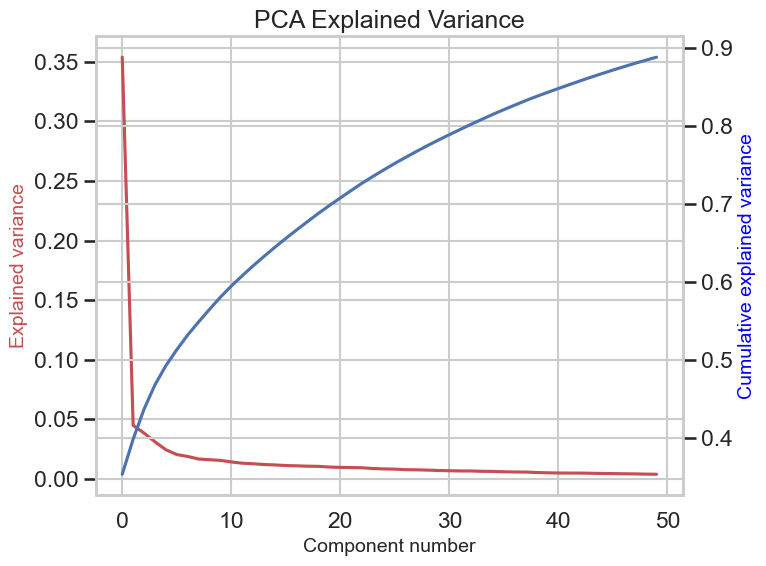

Cumulative variance explained by the first 20 components: 0.70


In [306]:
#  Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # only fit on training data


# Run PCA with 50 components  # source: wk 4 data
pca = PCA(n_components=50)  # calculate first 50 components; specifying how many compenents will be calculated
pca.fit(X_train_scaled)

# Explained variance plot (red)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(pca.explained_variance_ratio_,'r')
ax.set_xlabel("Component number", fontsize=14)
ax.set_ylabel("Explained variance", color="r", fontsize=14)

# Cumulative explained variance plot (blue)
ax2=ax.twinx()
ax2.plot(np.cumsum(pca.explained_variance_ratio_),'b')
ax2.set_ylabel("Cumulative explained variance", color="blue", fontsize=14)

plt.title('PCA Explained Variance')
fig.tight_layout()
plt.show()

# print variance explained by the first 20 components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"Cumulative variance explained by the first 20 components: {cumulative_variance[19]:.2f}")


Exploring without a set number of components to see if we captured enough information from just using 50 components. 

Source of code: https://www.kaggle.com/code/lonewolf95/classification-tutorial-with-pca-and-gridsearchcv

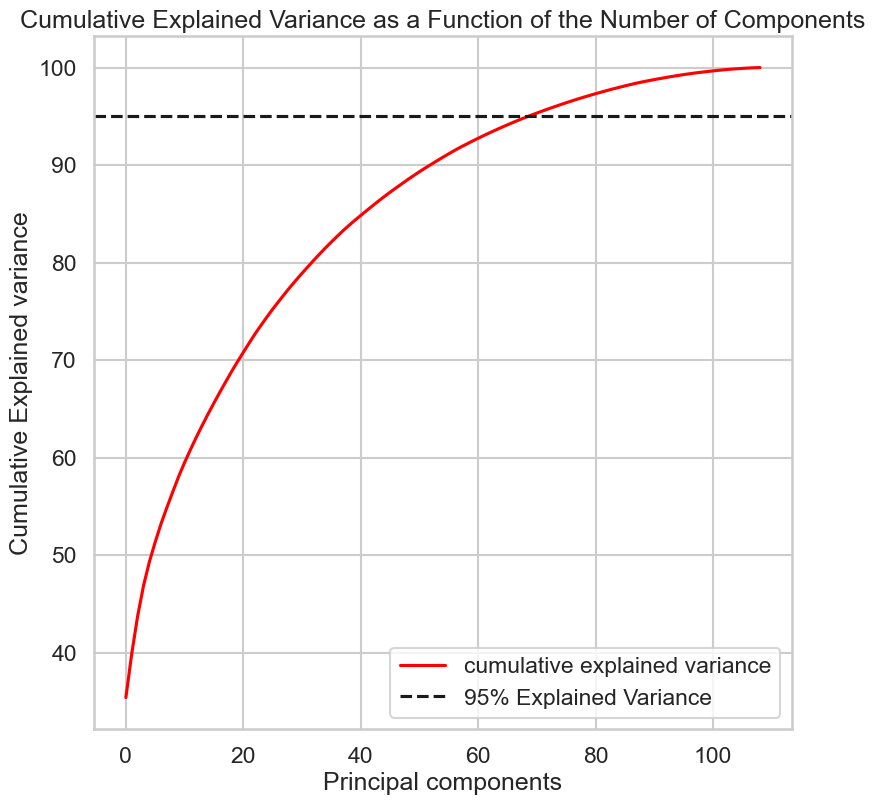

In [307]:
pca = PCA()
pca.fit(X_train_scaled)

cumsum = np.cumsum(pca.explained_variance_ratio_)*100
d = [n for n in range(len(cumsum))]

plt.figure(figsize=(9, 9))
plt.plot(d,cumsum, color = 'red',label='cumulative explained variance')
plt.title('Cumulative Explained Variance as a Function of the Number of Components')
plt.ylabel('Cumulative Explained variance')
plt.xlabel('Principal components')
plt.axhline(y = 95, color='k', linestyle='--', label = '95% Explained Variance')
plt.legend(loc='best')

For the sake of optimisation in each model, PCA will be tested in our models directly as a hyperparameter.

## 3.3 EXPLORATORY PIPELINE: RIDGE

Exploring ridge regularisation as our model in this section. 

Ridge handles multicollinearity and keeps all features


### without PCA

In [308]:
# we create the pipeline using a scaler and our model, ridge regression

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


We now need to do hyperparameter optimisation using a grid search to improve the performance of ridge

grid search : https://www.youtube.com/watch?v=TvB_3jVIHhg 

In [309]:
# create the hyperparameter grid
# ridge__alpha syntax: it references the Ridge step in the pipeline
param_grid_ridge = {'ridge__alpha': [0.1, 1, 10, 100, 200]}

scoring = {
    'R2': 'r2', 
    'MSE': 'neg_mean_squared_error'
}

# Run GridsearchCV and fit to data
grid_ridge = GridSearchCV(ridge_pipe, param_grid_ridge, cv=5, scoring=scoring, refit='R2', n_jobs=-1)

grid_ridge.fit(X_train, y_train)

# Extract Results and evaluate the model's performanc:
# Best hyperparameters:
best_params = grid_ridge.best_params_
best_idx = grid_ridge.best_index_

# Metrics
training_r2 = grid_ridge.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_ridge.cv_results_['std_test_R2'][best_idx]
training_mse = -grid_ridge.cv_results_['mean_test_MSE'][best_idx] # negate to get positive MSE
training_mse_std = grid_ridge.cv_results_['std_test_MSE'][best_idx]

print("=== Ridge WITHOUT PCA ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")
# this will automatically find the best L2 regularisation strenght

=== Ridge WITHOUT PCA ===
Best parameters: {'ridge__alpha': 200}
Best model CV R²: -0.0366 ± 0.0435
Best model CV MSE: 1644.58 ± 115.05


### with PCA

We will now run a ridge with a PCA due to the high-dimensionality of the data (116 freatures)

In [310]:
# Can add PCA to pipeline:

pipe_pca_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('ridge', Ridge())
])

pipe_pca_ridge.fit(X_train, y_train)


,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'


In [311]:
# Define hyperparameter grid
param_grid = {
    'pca__n_components': [5, 10, 15, 20, 30, 50],
    'ridge__alpha': [0.01, 0.1, 1, 10, 100, 200]
}

# set up scorting metrics for gridsearchCV
scoring = {
    'R2': 'r2', 
    'MSE': 'neg_mean_squared_error'
}

# set up GridSearchCV
grid = GridSearchCV(pipe_pca_ridge, param_grid, cv=5, scoring=scoring, refit='R2', n_jobs=-1)

grid.fit(X_train, y_train)

# Best hyperparameters (based on R2)
best_params = grid.best_params_
print(f"Best parameters:", best_params)

# metrics
best_idx = grid.best_index_

training_r2 = grid.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid.cv_results_['std_test_R2'][best_idx]

training_mse = -grid.cv_results_['mean_test_MSE'][best_idx]  # flip sign for MSE
training_mse_std = grid.cv_results_['std_test_MSE'][best_idx]

print("=== Ridge WITH PCA ===")
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")


Best parameters: {'pca__n_components': 5, 'ridge__alpha': 200}
=== Ridge WITH PCA ===
Best model CV R²: 0.0184 ± 0.0379
Best model CV MSE: 1559.50 ± 134.07


Ridge with PCA performs much better than just Ridge, as expected. It does explain only just 1.84% of the variance, and is generally unstable and weak, with not great generalisabtily. Since both are doing quite bad, but still better than linear regression, it makes sense to conitnue to explore other pipelines for this data. Their bad perfomance could also just be because the data is noisy, but to confirm this we will also explore lasso and elastic net to see if it we can get a better performance.


## 3.4 EXPLORING PIPELINE: LASSO

### Without PCA

In [312]:
#Create the pipeline

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))  # ensure convergence since high-dimensional data may require more iteration
])

In [313]:
# create hyperparameters:
param_grid = {
    'lasso__alpha': [0.01, 0.1, 1, 10, 50]  # regularization strengths
}

# define scoring:
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}

# run gridsearch and fit
grid_lasso = GridSearchCV(lasso_pipe, param_grid, cv=5, scoring=scoring, refit='R2', n_jobs=-1)
grid_lasso.fit(X_train, y_train)


,estimator,Pipeline(step...iter=10000))])
,param_grid,"{'lasso__alpha': [0.01, 0.1, ...]}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [314]:
# evaluate results and perfomance
best_params = grid_lasso.best_params_
best_idx = grid_lasso.best_index_

training_r2 = grid_lasso.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_lasso.cv_results_['std_test_R2'][best_idx]

training_mse = -grid_lasso.cv_results_['mean_test_MSE'][best_idx]
training_mse_std = grid_lasso.cv_results_['std_test_MSE'][best_idx]

print("=== Lasso WITHOUT PCA ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")

=== Lasso WITHOUT PCA ===
Best parameters: {'lasso__alpha': 10}
Best model CV R²: -0.0082 ± 0.0125
Best model CV MSE: 1604.49 ± 156.31


### With PCA

In [315]:
# Pipeline with PCA
lasso_pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('lasso', Lasso(max_iter=10000))
])

In [316]:
# Hyperparameter grid
param_grid_pca = {
   'pca__n_components': [5, 10, 15, 20, 30, 50],
   'lasso__alpha': [0.01, 0.1, 1, 10, 50]
}

# GridSearchCV
grid_lasso_pca =  GridSearchCV(lasso_pca_pipe, param_grid, cv=5, scoring=scoring, refit='R2', n_jobs=-1)
grid_lasso_pca.fit(X_train, y_train)


,estimator,Pipeline(step...iter=10000))])
,param_grid,"{'lasso__alpha': [0.01, 0.1, ...]}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [317]:
# Results and evaluate performance:

best_params_pca = grid_lasso_pca.best_params_
best_idx_pca = grid_lasso_pca.best_index_

training_r2_pca = grid_lasso_pca.cv_results_['mean_test_R2'][best_idx_pca]
training_r2_pca_std = grid_lasso_pca.cv_results_['std_test_R2'][best_idx_pca]

training_mse_pca = -grid_lasso_pca.cv_results_['mean_test_MSE'][best_idx_pca]
training_mse_pca_std = grid_lasso_pca.cv_results_['std_test_MSE'][best_idx_pca]


print("=== Lasso WITH PCA ===")
print("Best alpha:", best_params_pca)
print(f"Best model CV R²: {training_r2_pca:.4f} ± {training_r2_pca_std:.4f}")
print(f"Best model CV MSE: {training_mse_pca:.2f} ± {training_mse_pca_std:.2f}")

=== Lasso WITH PCA ===
Best alpha: {'lasso__alpha': 10}
Best model CV R²: 0.0235 ± 0.0218
Best model CV MSE: 1553.24 ± 146.74


Lasso with PCA is performing better with PCA, as expected, with a better perfomance than Ridge and PCA.

## 3.5 EXPLORING PIPELINE: ELASTIC NET

Elastic Net combines ridge and lasso

### without PCA

In [318]:
# define pipelines
# note that elastic net combines Lasso (L1) and Ridge (L2) penalties allowing for regularisation and feature selection

pipe_en = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

In [319]:
# define hyperparameter grid
# alpha: Overall regularization strength
# l1_ratio: Mix between L1 and L2: 0 → Ridge, 1 → Lasso, 0.5 → half-half

param_grid = {
    'elasticnet__alpha': [0.01, 0.1, 1, 10, 50],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [320]:
# GridSearchCV with cross-validation

# define scoring:
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}

# run gridsearch and fit
grid_en = GridSearchCV(pipe_en, param_grid, cv=5, scoring=scoring, refit='R2', n_jobs=-1)
grid_en.fit(X_train, y_train)


,estimator,Pipeline(step...iter=10000))])
,param_grid,"{'elasticnet__alpha': [0.01, 0.1, ...], 'elasticnet__l1_ratio': [0.1, 0.3, ...]}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [321]:
# results and evaluate performance
best_params=grid_en.best_params_
best_idx = grid_en.best_index_

training_r2 = grid_en.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_en.cv_results_['std_test_R2'][best_idx]

training_mse = -grid_en.cv_results_['mean_test_MSE'][best_idx]
training_mse_std = grid_en.cv_results_['std_test_MSE'][best_idx]

print("=== ElasticNet WITHOUT PCA ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")


=== ElasticNet WITHOUT PCA ===
Best parameters: {'elasticnet__alpha': 10, 'elasticnet__l1_ratio': 0.1}
Best model CV R²: 0.0210 ± 0.0196
Best model CV MSE: 1557.11 ± 144.74


Elastic Net slightly improves performance from ridge and lasso without PCA, likely because the L1 component allows it to focus on the most informative features

If interpretability is important, ElasticNet without PCA is easier because coefficients correspond to original features. If slight predictive improvement is prioritized, Lasso + PCA is marginally better.

However, we will explore ElasticNet with PCA as well to see if we can improve performance

### with PCA

In [322]:
# define pipelines
# note that elastic net combines Lasso (L1) and Ridge (L2) penalties allowing for regularisation and feature selection

pipe_en_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('elasticnet', ElasticNet(max_iter=10000))
])


# define hyperparameter grid

param_grid = {
    'pca__n_components': [5, 10, 15, 20, 30, 50],
    'elasticnet__alpha': [0.01, 0.1, 1, 10, 50],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [323]:
# GridSearchCV with cross-validation

# define scoring:
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}

# run gridsearch and fit
grid_en_pca = GridSearchCV(pipe_en_pca, param_grid, cv=5, scoring=scoring, refit='R2', n_jobs=-1)
grid_en_pca.fit(X_train, y_train)

,estimator,Pipeline(step...iter=10000))])
,param_grid,"{'elasticnet__alpha': [0.01, 0.1, ...], 'elasticnet__l1_ratio': [0.1, 0.3, ...], 'pca__n_components': [5, 10, ...]}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [324]:

# results and evaluate performance
best_params=grid_en_pca.best_params_
best_idx = grid_en_pca.best_index_

training_r2 = grid_en_pca.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_en_pca.cv_results_['std_test_R2'][best_idx]
training_mse = -grid_en_pca.cv_results_['mean_test_MSE'][best_idx]
training_mse_std = grid_en_pca.cv_results_['std_test_MSE'][best_idx]

print("=== ElasticNet WITH PCA ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")



=== ElasticNet WITH PCA ===
Best parameters: {'elasticnet__alpha': 10, 'elasticnet__l1_ratio': 0.7, 'pca__n_components': 5}
Best model CV R²: 0.0236 ± 0.0222
Best model CV MSE: 1553.04 ± 146.43


Elastic Net perfoms well, with our without PCA, but with PCA it performs the best so far, explaining 2.36% of variance

## 3.6 EXPLORING PIPELINE: SVR WITH RBF KERNELS
Exploring non-linear alternatives. SVR or support vector regression. It applies the principles of support vector machines to regression, basically trying to fit the best line within a margin of tolerance. Note that it can also reduce bias but it may increase variance. 

Source: https://medium.com/@anupchakole/data-science-series-part-5-deep-dive-into-regularization-clustering-knn-svm-and-dimension-e518b6752be5


In [325]:
# define the SVR pipeline

pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('svr', SVR(kernel='rbf'))
])

the hyperparameters in SVN:

C: regularization strength (like alpha in Ridge)

epsilon: margin of tolerance

kernel: linear or RBF (RBF can capture non-linear relationships)

gamma: for RBF kernel, controls flexibility

In [326]:
param_grid_svr = {
    'pca__n_components': [5, 10, 15, 20, 30, 50],
    'svr__C': [0.1, 1, 10, 50, 100],
    'svr__epsilon': [0.01, 0.1, 0.5, 1],
    'svr__gamma': ['scale', 'auto',  0.01, 0.1, 1]  # matters for RBF kernel
}

In [327]:
#GridSearchCV with cross-validation
# scoring
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}

#gridsearch and fitting
grid_svr = GridSearchCV(pipe_svr, param_grid_svr, cv=5, scoring=scoring, refit='R2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

,estimator,"Pipeline(step...svr', SVR())])"
,param_grid,"{'pca__n_components': [5, 10, ...], 'svr__C': [0.1, 1, ...], 'svr__epsilon': [0.01, 0.1, ...], 'svr__gamma': ['scale', 'auto', ...]}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


Important to note that this method is somewhat more computationally heavier

In [328]:
# Results and evaluate:

# Extract best hyperparameters
best_params = grid_svr.best_params_
best_idx = grid_svr.best_index_

# CV metrics for best model
training_r2 = grid_svr.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_svr.cv_results_['std_test_R2'][best_idx]

training_mse = -grid_svr.cv_results_['mean_test_MSE'][best_idx]
training_mse_std = grid_svr.cv_results_['std_test_MSE'][best_idx]

# Print results
print("=== SVR with RBF kernel ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")

=== SVR with RBF kernel ===
Best parameters: {'pca__n_components': 10, 'svr__C': 1, 'svr__epsilon': 1, 'svr__gamma': 0.01}
Best model CV R²: 0.0041 ± 0.0120
Best model CV MSE: 1585.58 ± 161.46


SVR preforms worse than Ridge+PCA, Lasso+PCA or Elastic Net (Both) on this dataset. This might be because of the noisiness of the singal (all the other models are struggling as well), because of the high-dimensionality of the data causing it to suffer, or that the dataset is smaller and therefore more sensetive to noise.


## 3.7 EXPLORATION PIPELINE: KNN REGRESSION
KNN is high-variance in high dimensions. It relies on distance metrics to classify data points based on the closest k neighbors where it assigns to the data point the average value of the nearest neighbours.

Source: https://medium.com/@anupchakole/data-science-series-part-5-deep-dive-into-regularization-clustering-knn-svm-and-dimension-e518b6752be5

In [329]:
# Define KNN Pipeline
# KNN is sensitivy to high dimensionality so we must include PCA to reduce the curse of dimensionality

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsRegressor())
])

Key KNN parameters:

n_neighbors: how many nearest neighbors to average

weights: uniform (all neighbors equally) or distance (closer neighbors count more)

Source: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

In [330]:
# Define hyperparameter grid

param_grid_knn = {
    'pca__n_components': [5, 10, 15, 20, 30, 50],
    'knn__n_neighbors': [3, 5, 7, 10, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # Minkowski distance: 1 = Manhattan, 2 = Euclidean
}

In [331]:
# GridSearchCV with cross-validation
#scoring
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}

#grid search and fit:
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring=scoring,refit='R2', n_jobs=-1)
grid_knn.fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance'], 'pca__n_components': [5, 10, ...]}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [332]:
# results and evaluation:

# Extract best hyperparameters
best_params = grid_knn.best_params_
best_idx = grid_knn.best_index_

# CV metrics for best model
training_r2 = grid_knn.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_knn.cv_results_['std_test_R2'][best_idx]

training_mse = -grid_knn.cv_results_['mean_test_MSE'][best_idx]
training_mse_std = grid_knn.cv_results_['std_test_MSE'][best_idx]

# Print results
print("=== KNN Regression ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")

=== KNN Regression ===
Best parameters: {'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'uniform', 'pca__n_components': 50}
Best model CV R²: -0.0348 ± 0.0316
Best model CV MSE: 1646.90 ± 166.85


KNN is not doing well, in fact it is doing the worst after linear. This is most likely because of the data's high dimenstionality and weak signal.

Do note that linear models (Elastic Net, Ridge) are more stable.

## 3.8 EXPLORATION PIPELINE: RandomForest

Random Forest uses an ensemble of decision trees to predict continious variables; builds many decision trees on different subsets of the data and averages their outputs to make a final prediction

Source:https://medium.com/@prathik.codes/mastering-randomforestregressor-in-scikit-learn-a-practical-guide-ba8615097100 

Why it is good to use: it handles non-linear relationships well; it is robust to overfitting; it can capture complex feature interactions; and it provides feature importances out of the box.

From my previous models we can see that there are weak linear correlations and that a non-linear model might capture the complex brain-behaviour brain regions bette. There is also high multicollinearity which tree models are robust to.

Because we have a somewhat small dataset, to mitigate this I will be implementing more conservative hyperparametrs, regularisation, and cross validation; furthermore to avoid overfitting I will be keep a limited max_depth and increase the min_samples_leaf and use max_features='sqrt'.

Additional source for this section: https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/

### RandomForest with conservative settings

In [333]:
# create the pipeline

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), # we still want to scale with RandomForest for consistency
    ('rf', RandomForestRegressor(random_state=42))
])

In [334]:
# Create the hyperparameter grid

param_grid_rf = {
    'rf__n_estimators':[100,300,500],
    'rf__max_depth':[5,10,15,None],
    'rf__min_samples_leaf':[5,10,20],
    'rf__max_features':['sqrt','log2']
}

In [335]:
# running gridsearchCV and fitting to data

#GridSearchCV with cross-validation
# scoring
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}

#gridsearch and fitting
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring=scoring, refit='R2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'rf__max_depth': [5, 10, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [5, 10, ...], 'rf__n_estimators': [100, 300, ...]}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


Note that this pipeline is computationally heavy.

In [336]:
# results and evaluation:

# Extract best hyperparameters
best_params = grid_rf.best_params_
best_idx = grid_rf.best_index_

# CV metrics for best model
training_r2 = grid_rf.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_rf.cv_results_['std_test_R2'][best_idx]

training_mse = -grid_rf.cv_results_['mean_test_MSE'][best_idx]
training_mse_std = grid_rf.cv_results_['std_test_MSE'][best_idx]


# Print results
print("=== RandomForest ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")

=== RandomForest ===
Best parameters: {'rf__max_depth': 5, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 100}
Best model CV R²: 0.0218 ± 0.0329
Best model CV MSE: 1554.47 ± 135.65


RandomForest does not perfom the best but it does not perform the worst.

## 3.9 EXPLORATION PIPELINE: Exploring XGBoost

Exploring XGBoost as a potential pipeline

XGBoost is goodd for handeling weak signals. In order to avoid overfitting, we will limit max_depth again. 

Source: https://xgboosting.com/xgboost-regularization-techniques/
 https://www.kaggle.com/code/carlosdg/xgboost-with-scikit-learn-pipeline-gridsearchcv

In [337]:
# Make the pipeline:

pipeline_xg = Pipeline([
    ('standard_scaler', StandardScaler()), 
    ('pca', PCA()), 
    ('XGBoost', xgb.XGBRegressor(random_state=42))
])

param_grid_xg = {
    'pca__n_components': [5, 10, 20],
    'XGBoost__max_depth': [3, 5, 7],
    'XGBoost__n_estimators': [50, 100],
    'XGBoost__learning_rate': [0.01, 0.1],
    'XGBoost__reg_alpha': [0, 0.1, 1],  # L1 regularization
    'XGBoost__reg_lambda': [1, 5, 10]   # L2 regularization

}

#GridSearchCV with cross-validation
# scoring
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}
grid_xg = GridSearchCV(pipeline_xg, param_grid_xg, cv=5, scoring=scoring, refit='R2', n_jobs=-1)

grid_xg.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'XGBoost__learning_rate': [0.01, 0.1], 'XGBoost__max_depth': [3, 5, ...], 'XGBoost__n_estimators': [50, 100], 'XGBoost__reg_alpha': [0, 0.1, ...], ...}"
,scoring,"{'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'R2'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


Note that this pipeline is very computationally heavy.

In [338]:
# results and evaluations: 
best_params = grid_xg.best_params_
best_idx = grid_xg.best_index_

# metrics for best model
training_r2 = grid_xg.cv_results_['mean_test_R2'][best_idx]
training_r2_std = grid_xg.cv_results_['std_test_R2'][best_idx]

training_mse = -grid_xg.cv_results_['mean_test_MSE'][best_idx]
training_mse_std = grid_xg.cv_results_['std_test_MSE'][best_idx]


# Print results
print("=== XGBoost ===")
print("Best parameters:", best_params)
print(f"Best model CV R²: {training_r2:.4f} ± {training_r2_std:.4f}")
print(f"Best model CV MSE: {training_mse:.2f} ± {training_mse_std:.2f}")

=== XGBoost ===
Best parameters: {'XGBoost__learning_rate': 0.01, 'XGBoost__max_depth': 3, 'XGBoost__n_estimators': 100, 'XGBoost__reg_alpha': 1, 'XGBoost__reg_lambda': 5, 'pca__n_components': 20}
Best model CV R²: 0.0187 ± 0.0196
Best model CV MSE: 1562.96 ± 167.96


## 4.0 Comparison of all explorational pipelines and visualisation of differences

Final comparison script of all possible piplelines to find the optimal one

Exploring a different way of running the models

In [339]:
#  Store models and hyperparameter grids
pipelines = {
    'Ridge': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge())
        ]),
        'param_grid': {'ridge__alpha': [0.1, 1, 10, 100, 200]}
    },
    'Ridge + PCA': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('ridge', Ridge())
        ]),
        'param_grid': {
            'pca__n_components': [5, 10, 15, 20, 30, 50],
            'ridge__alpha': [0.1, 1, 10, 100, 200]}
    },
    'Lasso': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('lasso', Lasso(max_iter=10000))
        ]),
        'param_grid': {'lasso__alpha': [0.01, 0.1, 1, 10, 50]}
    },
    'Lasso + PCA': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('lasso', Lasso(max_iter=10000))
        ]),
        'param_grid': {
            'pca__n_components': [5, 10, 15, 20, 30, 50],
            'lasso__alpha': [0.01, 0.1, 1, 10, 50]}
    },
    'ElasticNet': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('enet', ElasticNet(max_iter=10000))
        ]),
        'param_grid': {
            'enet__alpha': [0.01, 0.1, 1, 10, 50],
            'enet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },
    'ElasticNet+PCA': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('enet', ElasticNet(max_iter=10000))
        ]),
        'param_grid': {
            'pca__n_components': [5, 10, 15, 20, 30, 50],
            'enet__alpha': [0.01, 0.1, 1, 10, 50],
            'enet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },
    'SVR (RBF)': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('svr', SVR(kernel='rbf'))
        ]),
        'param_grid': {
            'pca__n_components': [5, 10, 15, 20, 30, 50],
            'svr__C': [0.1, 1, 10, 50, 100],
            'svr__gamma': ['scale', 'auto', 0.01, 0.1, 1],
            'svr__epsilon': [0.01, 0.1, 0.5, 1]
        }
    },
    'KNN': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('knn', KNeighborsRegressor())
        ]),
        'param_grid': {
            'pca__n_components': [5, 10, 15, 20, 30, 50],
            'knn__n_neighbors': [3, 5, 7, 10, 15],
            'knn__weights': ['uniform', 'distance'],
            'knn__p': [1, 2]
        }
    },
    'RandomForest': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('rf', RandomForestRegressor(random_state=42))
        ]),
        'param_grid': {
                'rf__n_estimators':[100,300,500],
                'rf__max_depth':[5,10,15,None],
                'rf__min_samples_leaf':[5,10,20],
                'rf__max_features':['sqrt','log2']
        }
    },
    'XGBoost': {
        'pipe': Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('XGBoost', xgb.XGBRegressor())
        ]),
        'param_grid': {
            'pca__n_components': [5, 10, 20],
            'XGBoost__max_depth': [3, 5, 7],
            'XGBoost__n_estimators': [50, 100],
            'XGBoost__learning_rate': [0.01, 0.1],
            'XGBoost__reg_alpha': [0, 0.1, 1], 
            'XGBoost__reg_lambda': [1, 5, 10] 
        }
    },
    'Linear Regression': {
        'pipe': Pipeline([
        ('scaler', StandardScaler()),
        ('linreg', LinearRegression())
    ]),
    'param_grid': {}
    
}

    }


In [340]:
# Scoring metrics
scoring = {'R2': 'r2', 'MSE': 'neg_mean_squared_error'}

# make a list to store results
results = []

# Loop through pipelines
for name, info in pipelines.items():
    print(f"Running GridSearchCV for {name} ...")
    
    grid = GridSearchCV(
        estimator=info['pipe'],
        param_grid=info['param_grid'],
        cv=5,
        scoring=scoring,
        refit='R2',  # pick best model based on R²
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    best_idx = grid.best_index_
    training_r2 = grid.cv_results_['mean_test_R2'][best_idx]
    training_mse = -grid.cv_results_['mean_test_MSE'][best_idx]  # negate to get positive MSE
    best_params = grid.best_params_
    
    results.append({
        'Model': name,
        'Best Params': best_params,
        'CV R²': round(training_r2, 4),
        'CV MSE': round(training_mse, 2)
    })


Running GridSearchCV for Ridge ...
Running GridSearchCV for Ridge + PCA ...
Running GridSearchCV for Lasso ...
Running GridSearchCV for Lasso + PCA ...
Running GridSearchCV for ElasticNet ...
Running GridSearchCV for ElasticNet+PCA ...
Running GridSearchCV for SVR (RBF) ...
Running GridSearchCV for KNN ...
Running GridSearchCV for RandomForest ...
Running GridSearchCV for XGBoost ...
Running GridSearchCV for Linear Regression ...


In [341]:
# Convert to DataFrame for a clean table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='CV R²', ascending=False).reset_index(drop=True)
print("\n=== Comparison of all pipelines ===")
print(results_df)


=== Comparison of all pipelines ===
                Model                                        Best Params  \
0      ElasticNet+PCA  {'enet__alpha': 10, 'enet__l1_ratio': 0.7, 'pc...   
1         Lasso + PCA      {'lasso__alpha': 10, 'pca__n_components': 15}   
2        RandomForest  {'rf__max_depth': 5, 'rf__max_features': 'log2...   
3          ElasticNet         {'enet__alpha': 10, 'enet__l1_ratio': 0.1}   
4             XGBoost  {'XGBoost__learning_rate': 0.01, 'XGBoost__max...   
5         Ridge + PCA      {'pca__n_components': 5, 'ridge__alpha': 200}   
6           SVR (RBF)  {'pca__n_components': 10, 'svr__C': 1, 'svr__e...   
7               Lasso                               {'lasso__alpha': 10}   
8                 KNN  {'knn__n_neighbors': 15, 'knn__p': 1, 'knn__we...   
9               Ridge                              {'ridge__alpha': 200}   
10  Linear Regression                                                 {}   

     CV R²   CV MSE  
0   0.0236  1553.04  
1   0.

As can be seen in these comparisons, Elastic Net and PCA did best, and as such it will be my optimal pipeline. 

However lets visualise the results.

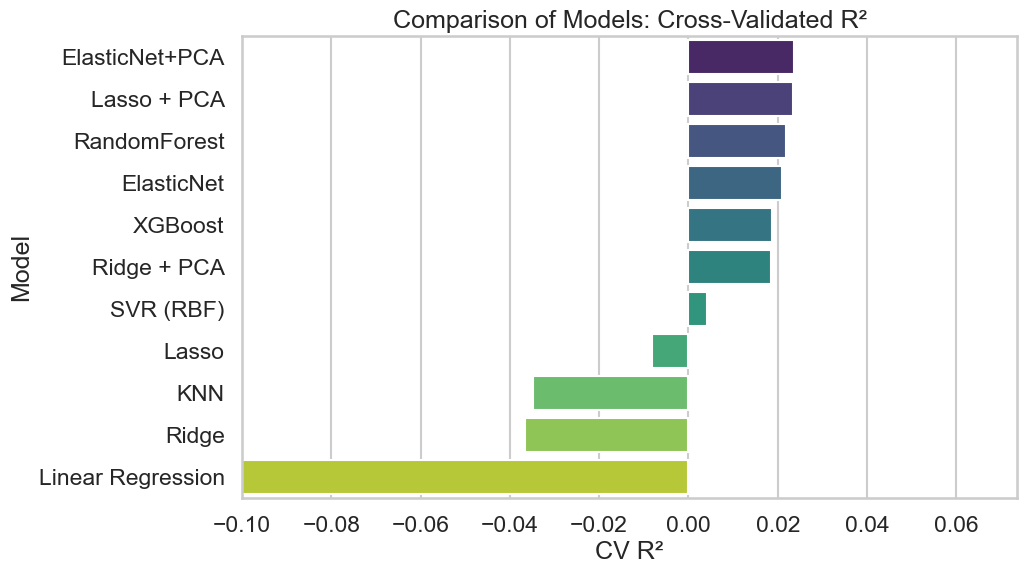

In [342]:
# Set a style for my graph
sns.set_theme(style='whitegrid', context='talk')

# Plot CV R²
plt.figure(figsize=(10,6))
sns.barplot(x='CV R²', y='Model', data=results_df, hue= 'Model', palette='viridis')
plt.title('Comparison of Models: Cross-Validated R²')
plt.xlabel('CV R²')
plt.ylabel('Model')
plt.xlim(-0.1, results_df['CV R²'].max() + 0.05)
plt.show()


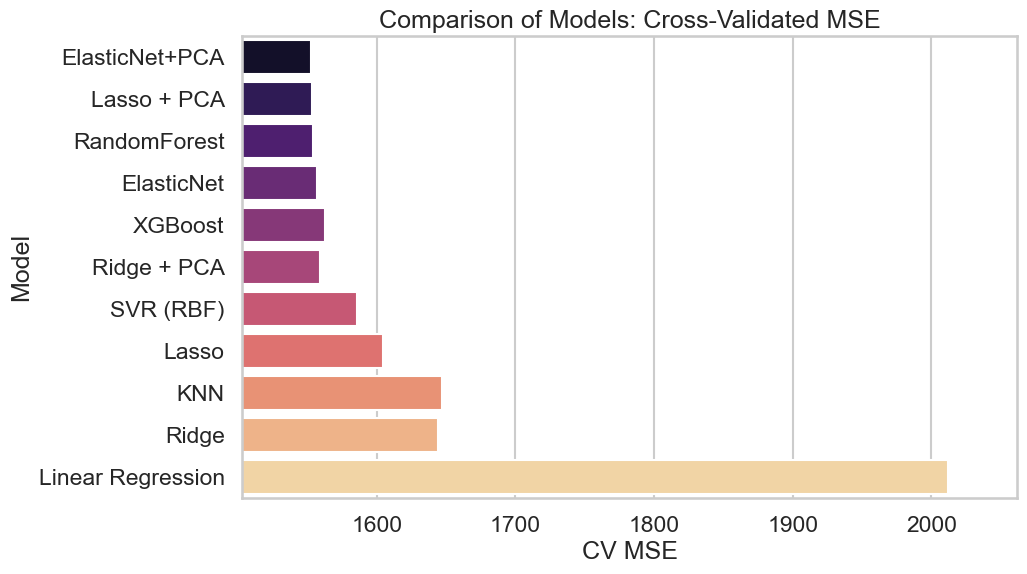

In [343]:
# Plotting MSE scores
plt.figure(figsize=(10,6))
sns.barplot(x='CV MSE', y='Model', data=results_df, hue='Model', palette='magma', legend=False)
plt.title('Comparison of Models: Cross-Validated MSE')
plt.xlabel('CV MSE')
plt.ylabel('Model')
plt.xlim(results_df['CV MSE'].min() - 50, results_df['CV MSE'].max() + 50)
plt.show()

## Permutation testing on top 2 models: Elastic Net with PCA and Lasso with PCA

source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.permutation_test_score.html#sklearn.model_selection.permutation_test_score

In [344]:
# For best model two models

# Elastic net and PCA
score_enp, perm_scores_enp, pvalue_enp = permutation_test_score(
    grid_en_pca.best_estimator_,
    X_train, y_train,
    scoring='r2',
    cv=5,
    n_permutations=100,
    n_jobs=-1
)

print("=== Permuation test on Elastic Net with PCA ===")
print(f"Actual R²: {score_enp:.4f}")
print(f"Permutation mean: {np.mean(perm_scores_enp):.4f}")
print(f"p-value: {pvalue_enp:.4f}")


# Lasso and PCA
score_lp, perm_scores_lp, pvalue_lp = permutation_test_score(
    grid_lasso_pca.best_estimator_,
    X_train, y_train,
    scoring='r2',
    cv=5,
    n_permutations=100,
    n_jobs=-1
)

print("=== Permuation test on Lasso with PCA ===")
print(f"Actual R²: {score_lp:.4f}")
print(f"Permutation mean: {np.mean(perm_scores_lp):.4f}")
print(f"p-value: {pvalue_lp:.4f}")


=== Permuation test on Elastic Net with PCA ===
Actual R²: 0.0236
Permutation mean: -0.0125
p-value: 0.0099
=== Permuation test on Lasso with PCA ===
Actual R²: 0.0235
Permutation mean: -0.0122
p-value: 0.0099


Both Elastic net with PCA and Lasso with PCA, achieved a statsitically signficant predictive performance (p<0.05). This confirms that there is a weak, but predictive signal. They have very similar cross-validated performance, so I will also be considering secondary features. 

Since elastic net is best for when features are strongly correlated, which we have, and since it also includes ridge L2, it will be more stable and robust. Additionally due to the high dimensionality of our data, it will be best to choose elastic net. 

Source: https://www.geeksforgeeks.org/machine-learning/lasso-vs-ridge-vs-elastic-net-ml/

Therefore ElasticNet + PCA was chosen because:

1. Best cross-validation performance (R² = 0.0236)
2. Statistical significance (permutation test p = 0.0099)
3. Robustness to multicollinearity (combines L1 + L2 penalties)
4. Stability with high-dimensional data (uses PCA n_components=5)
5. Better than Lasso+PCA due to Ridge component providing stability



## Test Best model on Hold Out Test Set

=== FINAL TEST SET PERFORMANCE (ElasticNet + PCA) ===
Test R²: 0.0822
Test MSE: 1520.37
Test MAE: 31.37

For comparison:
Training CV R²: 0.0236


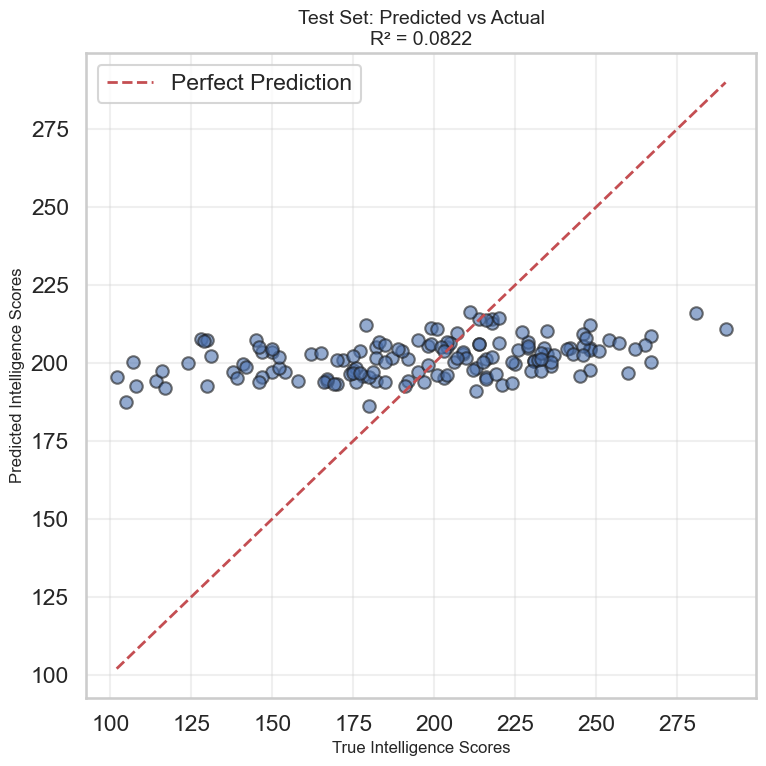

In [345]:
# Test best model (ElasticNet + PCA) on hold-out test set
best_model = grid_en_pca.best_estimator_

# Predict on test set
y_pred_test = best_model.predict(X_test)

# Calculate metrics
test_r2 = r2_score(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print("=== FINAL TEST SET PERFORMANCE (ElasticNet + PCA) ===")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"\nFor comparison:")
print(f"Training CV R²: 0.0236")

# Predicted vs Actual plot
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Intelligence Scores', fontsize=12)
plt.ylabel('Predicted Intelligence Scores', fontsize=12)
plt.title(f'Test Set: Predicted vs Actual\nR² = {test_r2:.4f}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary of Findings

  **Optimal Model:** ElasticNet + PCA (n_components=5, alpha=10, l1_ratio=0.7)

  **Performance:**
  - Cross-validation R² = 0.0236 (p = 0.0099)
  - Test R² = 0.0822
  - Test MAE = 31 points

  **Key Insights:**
  1. Weak but statistically significant relationship between brain structure and intelligence
  2. PCA essential - transformed negative R² to positive across all linear models
  3. Non-linear models (SVR, KNN) failed to improve performance
  4. Ensemble models (RF, XGBoost) comparable to linear but not better
  5. ElasticNet chosen for stability with correlated features and high dimensionality

  **Implications:**
  Static brain structure alone explains only ~8.22% of intelligence variance,
  suggesting dynamic brain activity and environmental factors play larger roles.